# Regressao de Consumo Eletrico: Dutch Energy

**Dataset:** [Energy consumption of the Netherlands](https://www.kaggle.com/datasets/lucabasa/dutch-energy)
**Tarefa principal:** regressao para prever o **consumo eletrico por conexao** (`consume_per_conn`, em kWh/conexao).
**Variavel bruta auditada:** `annual_consume` (kWh agregado por faixa de CEP), usada em EDA, limpeza e comparacoes.

O dataset contem dados de consumo de eletricidade e gas na Holanda, coletados por distribuidoras regionais. Cada registro agrega conexoes por faixa de CEP e ano.

Como as mesmas cidades e faixas de CEP aparecem em varios anos, um split aleatorio tende a ser otimista. A avaliacao final usa **split temporal por ano** para reduzir leakage.

## Melhorias implementadas (vs versao inicial)
- **zipcode_from** adicionado como feature (target encoding) — maior ganho individual: MAE 68 -> 40 kWh
- **K-fold target encoding** no treino para eliminar leakage das categoricas
- **Sem subsampling** para XGBoost/LightGBM (treino completo)
- **Hiperparametros ajustados**: mais arvores, learning rate menor, mais paciencia

## Modelos comparados

| Tradicionais | Boosting | Deep Learning |
|---|---|---|
| Linear Regression | XGBoost | MLP |
| Ridge / Lasso | LightGBM | |
| Random Forest | | |

## 1. Setup e imports

In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, gc
from pathlib import Path
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    median_absolute_error,
    r2_score,
)

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor, early_stopping, log_evaluation

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 100
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
print("Setup concluido.")


Setup concluido.


## 2. Configuracao e download do dataset

O notebook tenta resolver automaticamente os dados em `notebooks/data/` ou `data/`, para rodar tanto a partir da raiz do projeto quanto dentro da pasta `notebooks/`.

No Google Colab, o dataset e baixado automaticamente via Kaggle API.  
Localmente, baixe do [Kaggle](https://www.kaggle.com/datasets/lucabasa/dutch-energy), extraia os CSVs e coloque na pasta `notebooks/data/` ou `data/`.


In [102]:
def resolve_notebook_dir():
    cwd = Path.cwd()
    candidates = [
        cwd,
        cwd / "notebooks",
        cwd.parent / "notebooks",
    ]

    unique_candidates = []
    for candidate in candidates:
        if candidate not in unique_candidates:
            unique_candidates.append(candidate)

    for candidate in unique_candidates:
        data_dir = candidate / "data"
        if data_dir.exists() and list(data_dir.glob("*electr*")):
            return candidate

    for candidate in unique_candidates:
        if (candidate / "data").exists():
            return candidate

    return cwd


NOTEBOOK_DIR = resolve_notebook_dir()
DATA_DIR = NOTEBOOK_DIR / "data"
RESULTS_DIR = NOTEBOOK_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15
SPLIT_MODE = "temporal"  # temporal holdout if year exists; fallback to random

# Download automatico no Colab
import os
if "COLAB_RELEASE_TAG" in os.environ and not list(DATA_DIR.glob("*electr*")):
    print("Colab detectado. Baixando dataset do Kaggle...")
    os.system("pip install -q kaggle")

    from google.colab import files
    if not Path("/root/.kaggle/kaggle.json").exists():
        print("Faca upload do kaggle.json (Kaggle > Settings > API > Create New Token):")
        uploaded = files.upload()
        os.makedirs("/root/.kaggle", exist_ok=True)
        for fn, content in uploaded.items():
            with open(f"/root/.kaggle/{fn}", "wb") as f:
                f.write(content)
        os.chmod("/root/.kaggle/kaggle.json", 0o600)

    TMP = Path("/tmp/dutch-energy")
    os.system(f"kaggle datasets download -d lucabasa/dutch-energy -p {TMP} --unzip")

    DATA_DIR.mkdir(exist_ok=True)
    import shutil
    found = list(TMP.rglob("*electr*.csv"))
    for f in found:
        shutil.move(str(f), str(DATA_DIR / f.name))
    print(f"Download concluido. {len(found)} arquivos de eletricidade em {DATA_DIR}")

    if not found:
        print("Conteudo baixado:")
        for p in sorted(TMP.rglob("*")):
            print(f"  {p}")
else:
    print(f"Notebook dir resolvido: {NOTEBOOK_DIR.resolve()}")
    print(f"Buscando dados em {DATA_DIR.resolve()}")
    print(f"  Arquivos de eletricidade encontrados: {len(list(DATA_DIR.glob('*electr*')))}")


Notebook dir resolvido: C:\Users\guilh\Documents\Faculdade\IA\IA-RAG\notebooks
Buscando dados em C:\Users\guilh\Documents\Faculdade\IA\IA-RAG\notebooks\data
  Arquivos de eletricidade encontrados: 75


## 3. Carregamento dos dados

O dataset contem CSVs separados por tipo (eletricidade/gas) e por ano. Vamos carregar apenas os de eletricidade e concatenar tudo.

In [103]:
import re

elec_files = sorted(set(DATA_DIR.glob("*electr*")))

if not elec_files:
    raise FileNotFoundError(
        f"Nenhum CSV de eletricidade encontrado em {DATA_DIR.resolve()}. "
        "Baixe o dataset do Kaggle e extraia aqui."
    )

USE_COLS = [
    "net_manager", "purchase_area", "city", "zipcode_from",
    "num_connections", "delivery_perc", "perc_of_active_connections",
    "type_of_connection", "type_conn_perc", "annual_consume",
    "annual_consume_lowtarif_perc", "smartmeter_perc",
]

NUM_COLS = [
    "num_connections", "delivery_perc", "perc_of_active_connections",
    "type_conn_perc", "annual_consume", "annual_consume_lowtarif_perc",
    "smartmeter_perc",
]

frames = []
for fp in sorted(elec_files):
    header = pd.read_csv(fp, nrows=0).columns.tolist()
    cols = [c for c in USE_COLS if c in header]

    chunk = pd.read_csv(fp, usecols=cols, dtype=str, low_memory=False)

    for col in NUM_COLS:
        if col in chunk.columns:
            chunk[col] = pd.to_numeric(chunk[col], errors="coerce").astype("float32")

    for col in ["net_manager", "purchase_area", "city", "type_of_connection", "zipcode_from"]:
        if col in chunk.columns:
            chunk[col] = chunk[col].astype("category")

    match = re.search(r"(20\d{2})", fp.stem)
    if match:
        chunk["year"] = np.int16(int(match.group(1)))

    print(f"  {fp.name}: {len(chunk):>9,} registros")
    frames.append(chunk)

raw_df = pd.concat(frames, ignore_index=True)
del frames; gc.collect()
print()
print(f"Total: {len(raw_df):,} registros | Memoria: {raw_df.memory_usage(deep=True).sum()/1e6:.1f} MB")
print(f"  zipcode_from: {raw_df['zipcode_from'].nunique():,} valores unicos")
raw_df.head()

  coteq_electricity_2013.csv:     2,503 registros
  coteq_electricity_2014.csv:     2,503 registros
  coteq_electricity_2015.csv:     2,503 registros
  coteq_electricity_2016.csv:     2,503 registros
  coteq_electricity_2017.csv:     2,503 registros
  coteq_electricity_2018.csv:     2,503 registros
  coteq_electricity_2019.csv:     2,563 registros
  coteq_electricity_2020.csv:     2,575 registros
  endinet_electricity_01012011.csv:     5,743 registros
  endinet_electricity_01012012.csv:     5,795 registros
  endinet_electricity_01012013.csv:     5,883 registros
  endinet_electricity_01012014.csv:     4,546 registros
  endinet_electricity_01012015.csv:     4,550 registros
  endinet_electricity_01012016.csv:     4,565 registros
  enduriselectricity_01012013.csv:     9,559 registros
  enduriselectricity_01012014.csv:     9,572 registros
  enduriselectricity_01012015.csv:     9,609 registros
  enduriselectricity_01012016.csv:     9,646 registros
  enduriselectricity_01012017.csv:     9,699

,net_manager,purchase_area,zipcode_from,city,num_connections,delivery_perc,perc_of_active_connections,type_conn_perc,type_of_connection,annual_consume,annual_consume_lowtarif_perc,smartmeter_perc,year
0,Coteq Netbeheer BV,Netbeheerder Centraal Overijssel B.V.,7468CP,ENTER,19.0,89.470001,94.739998,89.0,1x35,4122.0,89.470001,0.0,2013
1,Coteq Netbeheer BV,Netbeheerder Centraal Overijssel B.V.,7471AB,GOOR,37.0,100.000000,100.000000,86.0,1x35,1800.0,94.589996,0.0,2013
2,Coteq Netbeheer BV,Netbeheerder Centraal Overijssel B.V.,7471AC,GOOR,16.0,100.000000,100.000000,100.0,1x35,1315.0,100.000000,0.0,2013
3,Coteq Netbeheer BV,Netbeheerder Centraal Overijssel B.V.,7471AD,GOOR,25.0,92.000000,84.000000,44.0,1x35,6379.0,92.000000,0.0,2013
4,Coteq Netbeheer BV,Netbeheerder Centraal Overijssel B.V.,7471AG,GOOR,14.0,85.709999,100.000000,36.0,1x35,4404.0,92.860001,0.0,2013


In [104]:
print("Colunas:", list(raw_df.columns))
print("\nTipos:")
print(raw_df.dtypes)
print("\nNulos:")
print(raw_df.isnull().sum())
print("\nDescritivas:")
raw_df.describe()

Colunas: ['net_manager', 'purchase_area', 'zipcode_from', 'city', 'num_connections', 'delivery_perc', 'perc_of_active_connections', 'type_conn_perc', 'type_of_connection', 'annual_consume', 'annual_consume_lowtarif_perc', 'smartmeter_perc', 'year']

Tipos:
net_manager                         str
purchase_area                       str
zipcode_from                        str
city                                str
num_connections                 float32
delivery_perc                   float32
perc_of_active_connections      float32
type_conn_perc                  float32
type_of_connection                  str
annual_consume                  float32
annual_consume_lowtarif_perc    float32
smartmeter_perc                 float32
year                              int16
dtype: object

Nulos:
net_manager                      29224
purchase_area                   886657
zipcode_from                         0
city                                 0
num_connections                      7
delive

,num_connections,delivery_perc,perc_of_active_connections,type_conn_perc,annual_consume,annual_consume_lowtarif_perc,smartmeter_perc,year
count,4.077345e+06,4.075283e+06,4.075865e+06,3.884802e+06,4.077352e+06,4.064084e+06,4.064084e+06,4.077352e+06
mean,2.326049e+01,9.591370e+01,9.691261e+01,7.545778e+01,4.450214e+03,5.301489e+01,2.357910e+01,2.014785e+03
std,1.550751e+01,9.385684e+00,9.580210e+00,1.976434e+01,3.613797e+03,3.072666e+01,3.257335e+01,3.348562e+00
min,1.379000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.009000e+03
25%,1.500000e+01,9.545000e+01,1.000000e+02,5.900000e+01,2.677000e+03,2.857000e+01,0.000000e+00,2.012000e+03
50%,2.000000e+01,1.000000e+02,1.000000e+02,7.800000e+01,3.475000e+03,4.920000e+01,6.250000e+00,2.015000e+03
75%,2.600000e+01,1.000000e+02,1.000000e+02,9.400000e+01,4.680000e+03,8.261000e+01,3.636000e+01,2.018000e+03
max,1.330000e+03,1.000000e+02,1.000000e+02,1.000000e+02,4.299312e+05,1.000000e+02,1.000000e+02,2.020000e+03


## 4. Pre-processamento

Colunas principais:
- `net_manager`: distribuidora regional
- `purchase_area`: area de compra
- `street`, `zipcode_from`, `zipcode_to`, `city`: localizacao
- `num_connections`: numero de conexoes na faixa de CEP
- `delivery_perc`: percentual do consumo liquido
- `perc_of_active_connections`: percentual de conexoes ativas
- `type_of_connection`: tipo principal de conexao
- `type_conn_perc`: percentual do tipo principal
- `annual_consume`: consumo anual agregado em kWh (usado para auditoria e limpeza)
- `annual_consume_lowtarif_perc`: percentual em horario de tarifa baixa
- `smartmeter_perc`: percentual de medidores inteligentes

A modelagem final usa `consume_per_conn` porque isso reduz a dependencia direta do tamanho do agregado (`num_connections`) e gera uma tarefa mais estavel.


In [105]:
ANNUAL_CONSUME_COL = "annual_consume"  # variavel bruta para auditoria e filtros
TARGET = "consume_per_conn"            # alvo de modelagem: kWh por conexao
TARGET_UNIT = "kWh/conexao"

df = raw_df.copy()

if "year" in df.columns:
    print(f"Anos disponiveis: {sorted(df['year'].unique())}")
else:
    print("Coluna 'year' nao encontrada.")

# Remover registros sem consumo ou com consumo negativo
before = len(df)
df = df[df[ANNUAL_CONSUME_COL].notna() & (df[ANNUAL_CONSUME_COL] > 0)].copy()
print(f"Removidos {before - len(df)} registros sem consumo valido")

# Remover outliers extremos do consumo agregado (acima do percentil 99.5)
q_high = df[ANNUAL_CONSUME_COL].quantile(0.995)
before = len(df)
df = df[df[ANNUAL_CONSUME_COL] <= q_high].copy()
print(f"Removidos {before - len(df)} outliers (>{q_high:.0f} kWh)")

print(f"\nDataset limpo: {len(df):,} registros")
del raw_df; gc.collect()
df[ANNUAL_CONSUME_COL].describe()


Anos disponiveis: [np.int16(2009), np.int16(2010), np.int16(2011), np.int16(2012), np.int16(2013), np.int16(2014), np.int16(2015), np.int16(2016), np.int16(2017), np.int16(2018), np.int16(2019), np.int16(2020)]
Removidos 1855 registros sem consumo valido
Removidos 20378 outliers (>24768 kWh)

Dataset limpo: 4,055,119 registros


count    4.055119e+06
mean     4.318705e+03
std      3.035512e+03
min      2.600000e-01
25%      2.673830e+03
50%      3.468000e+03
75%      4.650000e+03
max      2.476800e+04
Name: annual_consume, dtype: float64

## 5. Analise geral do dataset e EDA

Esta secao responde tres perguntas:
1. O dataset esta equilibrado ao longo dos anos?
2. Quais colunas tem missing e alta cardinalidade?
3. O alvo bruto (`annual_consume`) e o alvo normalizado (`consume_per_conn`) sao muito assimetricos?


,Metrica,Valor
0,Registros apos limpeza inicial,4055119
1,Anos disponiveis,12
2,Distribuidoras,19
3,Areas de compra,17
4,Cidades,2631
5,Tipos de conexao,25
6,Cidades em mais de 1 ano,2610


,missing_pct
purchase_area,21.75
type_conn_perc,4.68
type_of_connection,2.64
net_manager,0.72
annual_consume_lowtarif_perc,0.32
smartmeter_perc,0.32
delivery_perc,0.05
perc_of_active_connections,0.04
num_connections,0.00
consume_per_conn_tmp,0.00


,annual_consume_kwh,consume_per_conn_kwh
count,4055119.000,4055112.000
mean,4318.705,227.981
std,3035.512,203.137
min,0.260,0.014
25%,2673.830,116.692
50%,3468.000,174.217
75%,4650.000,264.467
95%,10469.000,577.500
99%,17959.000,1128.846
max,24768.000,5034.341


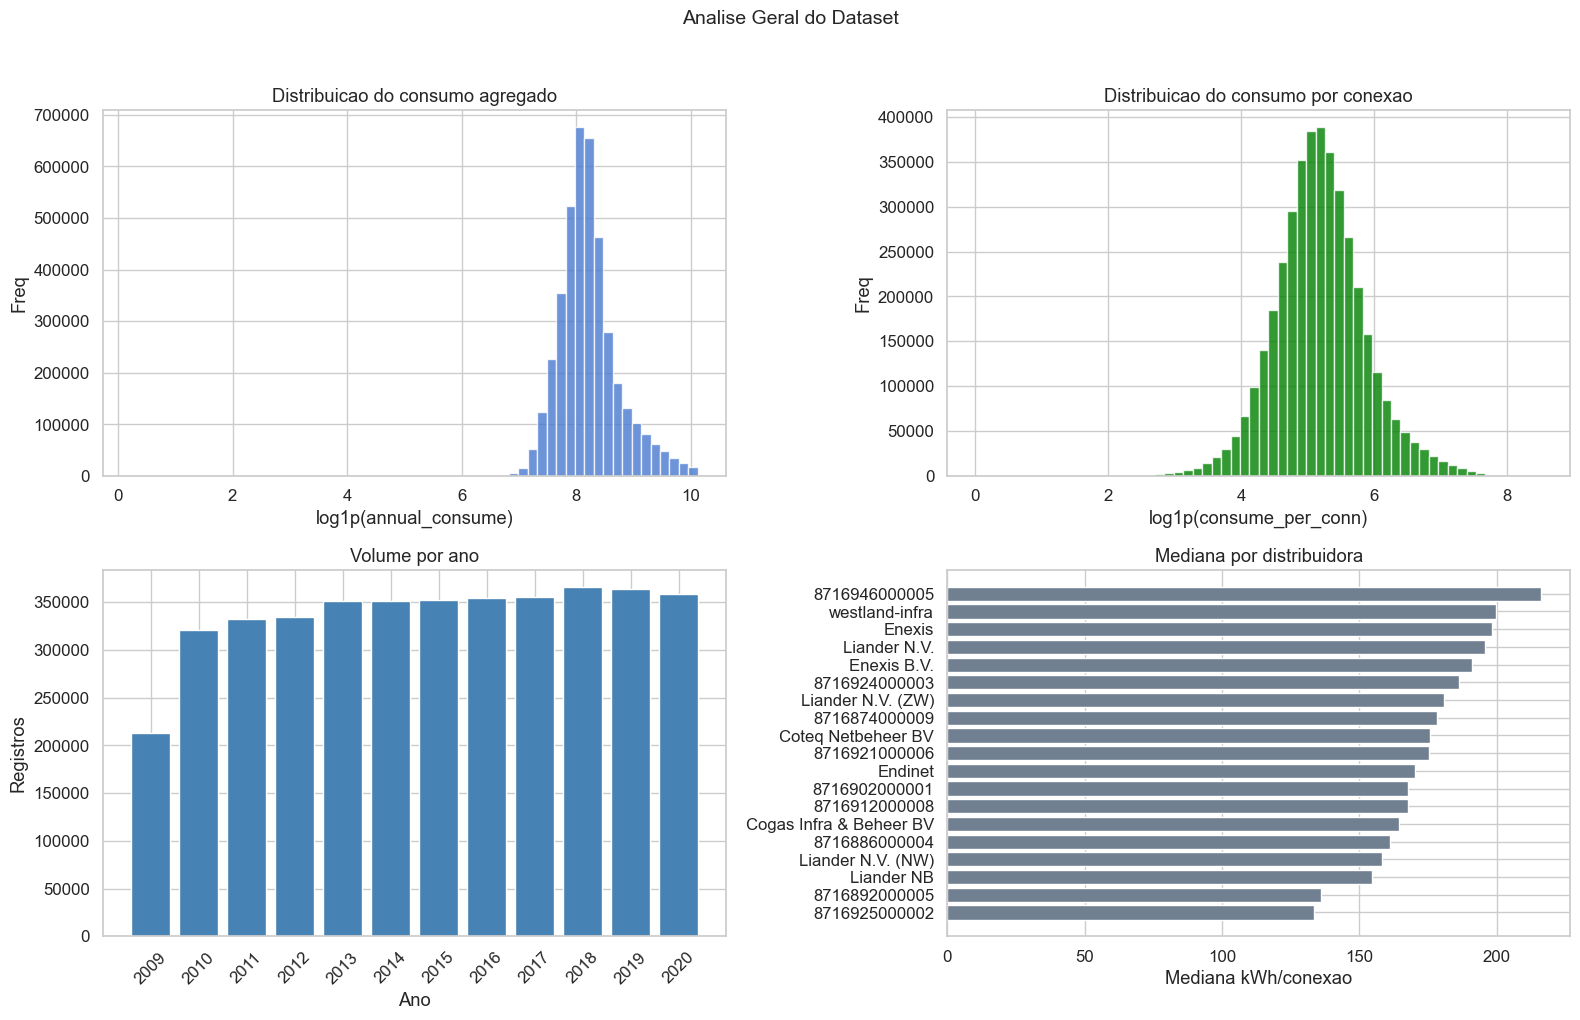

In [106]:
audit_df = df.copy()
audit_df["consume_per_conn_tmp"] = (
    audit_df[ANNUAL_CONSUME_COL] / audit_df["num_connections"].replace(0, np.nan)
).astype("float32")

dataset_audit = pd.DataFrame(
    [
        {"Metrica": "Registros apos limpeza inicial", "Valor": len(audit_df)},
        {"Metrica": "Anos disponiveis", "Valor": audit_df["year"].nunique() if "year" in audit_df.columns else np.nan},
        {"Metrica": "Distribuidoras", "Valor": audit_df["net_manager"].nunique(dropna=True) if "net_manager" in audit_df.columns else np.nan},
        {"Metrica": "Areas de compra", "Valor": audit_df["purchase_area"].nunique(dropna=True) if "purchase_area" in audit_df.columns else np.nan},
        {"Metrica": "Cidades", "Valor": audit_df["city"].nunique(dropna=True) if "city" in audit_df.columns else np.nan},
        {"Metrica": "Tipos de conexao", "Valor": audit_df["type_of_connection"].nunique(dropna=True) if "type_of_connection" in audit_df.columns else np.nan},
        {
            "Metrica": "Cidades em mais de 1 ano",
            "Valor": int(
                (
                    audit_df.groupby("city")["year"].nunique() > 1
                ).sum()
            ) if {"city", "year"}.issubset(audit_df.columns) else np.nan,
        },
    ]
)

missing_summary = (
    audit_df.isna().mean().mul(100).sort_values(ascending=False).rename("missing_pct")
)

target_summary = pd.DataFrame(
    {
        "annual_consume_kwh": audit_df[ANNUAL_CONSUME_COL].describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99]),
        "consume_per_conn_kwh": audit_df["consume_per_conn_tmp"].describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99]),
    }
).round(3)

display(dataset_audit)
display(missing_summary[missing_summary > 0].round(2).to_frame())
display(target_summary)

dataset_audit.to_csv(RESULTS_DIR / "dataset_audit_summary.csv", index=False)
missing_summary.to_csv(RESULTS_DIR / "missing_summary.csv")
target_summary.to_csv(RESULTS_DIR / "target_distribution_summary.csv")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Analise Geral do Dataset", fontsize=14, y=1.02)

ax = axes[0, 0]
ax.hist(np.log1p(audit_df[ANNUAL_CONSUME_COL]), bins=60, edgecolor="white", alpha=0.8)
ax.set_xlabel("log1p(annual_consume)")
ax.set_ylabel("Freq")
ax.set_title("Distribuicao do consumo agregado")

ax = axes[0, 1]
ax.hist(np.log1p(audit_df["consume_per_conn_tmp"].dropna()), bins=60, edgecolor="white", alpha=0.8, color="green")
ax.set_xlabel("log1p(consume_per_conn)")
ax.set_ylabel("Freq")
ax.set_title("Distribuicao do consumo por conexao")

ax = axes[1, 0]
if "year" in audit_df.columns:
    yearly_counts = audit_df["year"].value_counts().sort_index()
    ax.bar(yearly_counts.index.astype(str), yearly_counts.values, color="steelblue")
    ax.set_xlabel("Ano")
    ax.set_ylabel("Registros")
    ax.set_title("Volume por ano")
    ax.tick_params(axis="x", rotation=45)

ax = axes[1, 1]
if "net_manager" in audit_df.columns:
    manager_stats = (
        audit_df.groupby("net_manager")["consume_per_conn_tmp"]
        .median()
        .sort_values(ascending=False)
    )
    ax.barh(manager_stats.index[::-1], manager_stats.values[::-1], color="slategray")
    ax.set_xlabel("Mediana kWh/conexao")
    ax.set_title("Mediana por distribuidora")

plt.tight_layout()
plt.show()


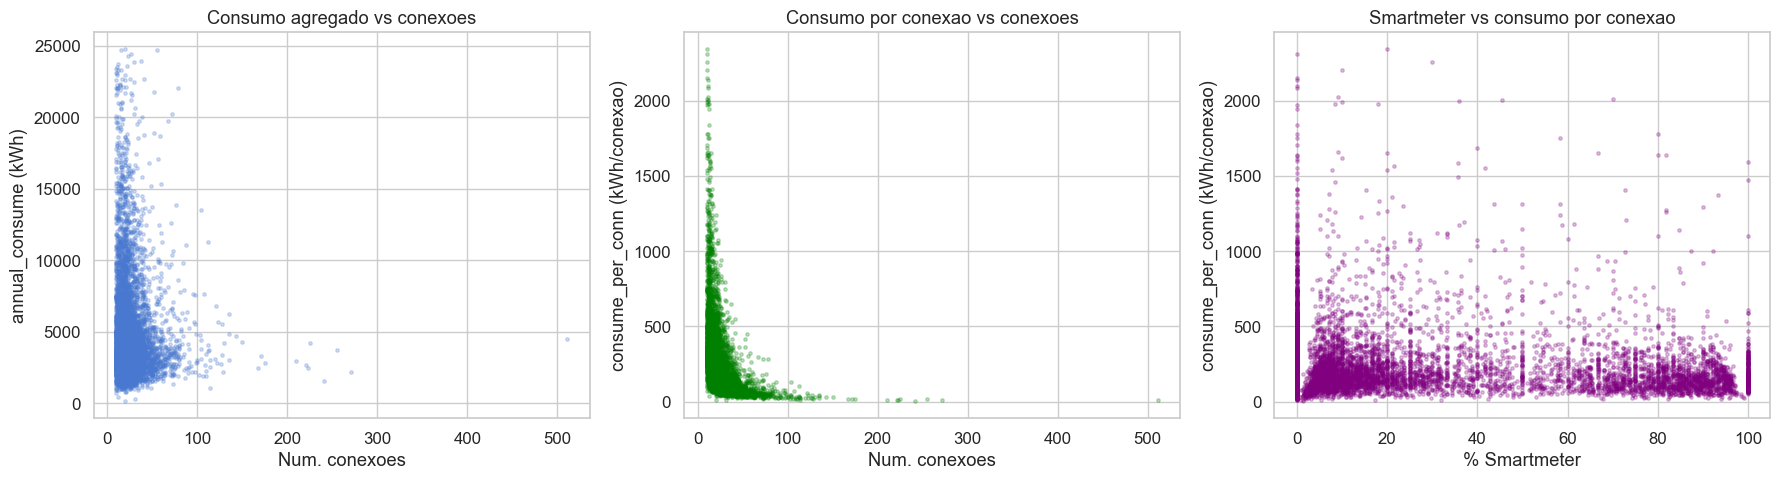

In [107]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sample = audit_df.sample(min(10000, len(audit_df)), random_state=SEED)

ax = axes[0]
ax.scatter(sample["num_connections"], sample[ANNUAL_CONSUME_COL], alpha=0.25, s=6)
ax.set_xlabel("Num. conexoes")
ax.set_ylabel("annual_consume (kWh)")
ax.set_title("Consumo agregado vs conexoes")

ax = axes[1]
ax.scatter(sample["num_connections"], sample["consume_per_conn_tmp"], alpha=0.25, s=6, color="green")
ax.set_xlabel("Num. conexoes")
ax.set_ylabel("consume_per_conn (kWh/conexao)")
ax.set_title("Consumo por conexao vs conexoes")

ax = axes[2]
if "smartmeter_perc" in sample.columns:
    ax.scatter(sample["smartmeter_perc"], sample["consume_per_conn_tmp"], alpha=0.25, s=6, color="purple")
    ax.set_xlabel("% Smartmeter")
    ax.set_ylabel("consume_per_conn (kWh/conexao)")
    ax.set_title("Smartmeter vs consumo por conexao")

plt.tight_layout()
plt.show()


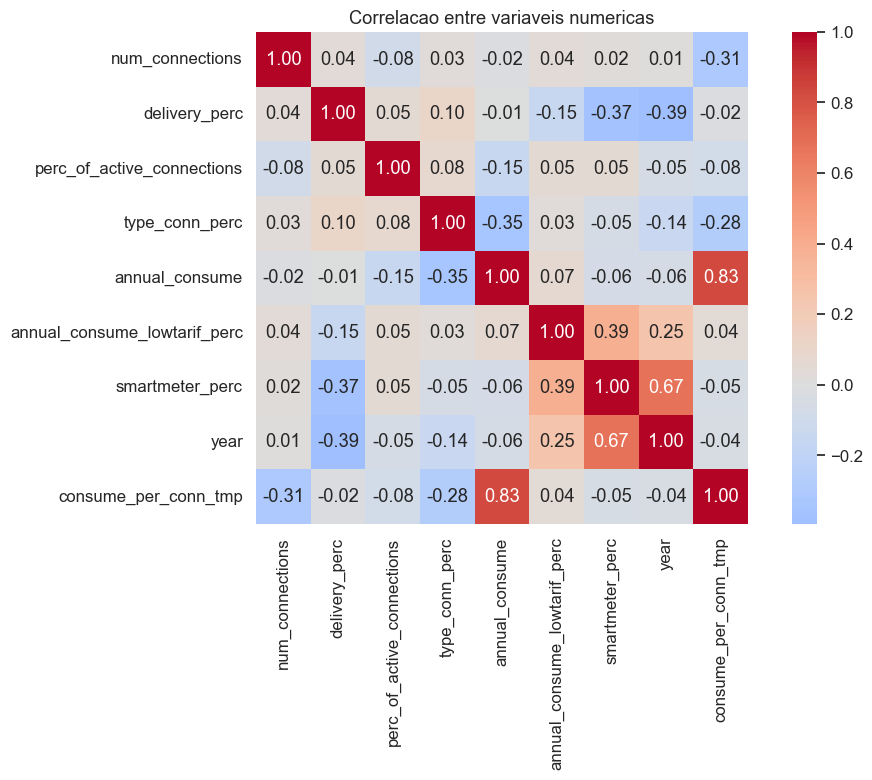

In [108]:
# Matriz de correlacao das variaveis numericas mais relevantes
corr_df = audit_df.copy()
num_cols = corr_df.select_dtypes(include=[np.number]).columns.tolist()
if len(num_cols) > 2:
    corr = corr_df[num_cols].corr(numeric_only=True)
    plt.figure(figsize=(11, 8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
    plt.title("Correlacao entre variaveis numericas")
    plt.tight_layout()
    plt.show()


## 6. Feature engineering

Estrategia:
- Modelar  para reduzir dependencia do tamanho do agregado
- Extrair a amperagem do  (ex:  -> )
- Criar proxies operacionais (, , )
- Usar **k-fold target encoding** em categoricas de alta cardinalidade (, , , )
  -  e o sinal mais forte: correlacao r=0.77 entre consumo do mesmo CEP em 2015 vs 2019
  - K-fold evita leakage: o encoding de cada linha usa apenas os outros folds do treino
- Split temporal para evitar que informacao de anos futuros contamine o treino

In [109]:
def parse_amperage(conn_str):
    """Extrai amperagem total de strings como '3x25' -> 75, '1x35' -> 35."""
    if pd.isna(conn_str) or conn_str == "nan":
        return np.nan
    m = re.match(r"(\d+)x(\d+)", str(conn_str).strip())
    if m:
        return int(m.group(1)) * int(m.group(2))
    return np.nan


def create_features(df):
    df = df.copy()

    if "type_of_connection" in df.columns:
        df["amperage"] = df["type_of_connection"].apply(parse_amperage).astype("float32")

    if "num_connections" in df.columns:
        safe_connections = df["num_connections"].replace(0, np.nan)
        df["consume_per_conn"] = (df[ANNUAL_CONSUME_COL] / safe_connections).astype("float32")
        df["log_num_connections"] = np.log1p(df["num_connections"]).astype("float32")

        if "perc_of_active_connections" in df.columns:
            df["active_connections"] = (
                df["num_connections"] * df["perc_of_active_connections"] / 100.0
            ).astype("float32")

        if "smartmeter_perc" in df.columns:
            df["smartmeter_connections"] = (
                df["num_connections"] * df["smartmeter_perc"] / 100.0
            ).astype("float32")

    if "consume_per_conn" in df.columns:
        q_cpc = df["consume_per_conn"].quantile(0.995)
        before = len(df)
        df = df[df["consume_per_conn"] <= q_cpc].copy()
        print(f"  Outliers consume_per_conn removidos: {before - len(df)} (>{q_cpc:.1f} kWh/conn)")

    if "amperage" in df.columns and "num_connections" in df.columns:
        df["total_capacity"] = (df["amperage"] * df["num_connections"]).astype("float32")

    if "annual_consume_lowtarif_perc" in df.columns:
        df["hightarif_perc"] = (100.0 - df["annual_consume_lowtarif_perc"]).astype("float32")

    # zipcode_from incluido no encoding (sinal mais forte do dataset)
    cat_cols_to_encode = [
        col for col in ["zipcode_from", "city", "purchase_area", "net_manager"]
        if col in df.columns
    ]

    before = len(df)
    df.dropna(subset=["consume_per_conn"], inplace=True)
    print(f"  Registros apos limpeza: {len(df):,} (removidos {before - len(df)})")

    return df, cat_cols_to_encode


print("Feature Engineering...")
feat_df, CAT_COLS_TO_ENCODE = create_features(df)
del df; gc.collect()

print(f"  Shape: {feat_df.shape}")
print("  Novas colunas: amperage, consume_per_conn, log_num_connections, active_connections, smartmeter_connections, total_capacity, hightarif_perc")
print(f"  Categoricas para target encoding: {CAT_COLS_TO_ENCODE}")
feat_df[["amperage", "consume_per_conn", "total_capacity"]].describe()

Feature Engineering...
  Outliers consume_per_conn removidos: 20283 (>1391.1 kWh/conn)
  Registros apos limpeza: 4,034,836 (removidos 0)
  Shape: (4034836, 20)
  Novas colunas: amperage, consume_per_conn, log_num_connections, active_connections, smartmeter_connections, total_capacity, hightarif_perc
  Categoricas para target encoding: ['zipcode_from', 'city', 'purchase_area', 'net_manager']


,amperage,consume_per_conn,total_capacity
count,3.259974e+06,4.034836e+06,3.259974e+06
mean,4.542655e+01,2.206086e+02,1.073865e+03
std,2.170486e+01,1.740287e+02,9.445113e+02
min,6.000000e+00,1.368421e-02,6.000000e+01
25%,2.500000e+01,1.164074e+02,5.250000e+02
50%,3.500000e+01,1.735789e+02,8.250000e+02
75%,7.500000e+01,2.624286e+02,1.350000e+03
max,2.400000e+02,1.391069e+03,7.830000e+04


## 7. Selecao de features, k-fold target encoding e split temporal

O **k-fold target encoding** corrige o leakage do encoding simples:
para cada linha do treino, a media do target e calculada apenas nos outros folds.
Val e test usam a media global do treino completo.

O split temporal usa os 2 ultimos anos para teste e os 2 anteriores para validacao.


In [110]:
EXCLUDE = [
    TARGET, "annual_consume", "street", "zipcode_to", "city",
    "net_manager", "purchase_area", "type_of_connection",
]

NUM_FEAT_COLS = [
    c for c in feat_df.columns
    if c not in EXCLUDE and feat_df[c].dtype in [np.float64, np.float32, np.int64, np.int32, np.int16]
]

essential = [c for c in NUM_FEAT_COLS if c not in [f"{cat}_te" for cat in CAT_COLS_TO_ENCODE]]
model_df = feat_df[NUM_FEAT_COLS + [TARGET] + CAT_COLS_TO_ENCODE].dropna(
    subset=essential + [TARGET]
).copy()
del feat_df; gc.collect()
print(f"Registros para modelagem: {len(model_df):,}")

model_df["log_target"] = np.log1p(model_df[TARGET]).astype("float32")

X_full = model_df.drop(columns=[TARGET, "log_target"])
y_full = model_df["log_target"]

years_available = sorted(model_df["year"].dropna().unique().tolist()) if "year" in model_df.columns else []

if SPLIT_MODE == "temporal" and len(years_available) >= 6:
    test_years = years_available[-2:]
    val_years = years_available[-4:-2]
    train_years = [y for y in years_available if y not in val_years + test_years]

    train_mask = X_full["year"].isin(train_years)
    val_mask   = X_full["year"].isin(val_years)
    test_mask  = X_full["year"].isin(test_years)

    X_train = X_full.loc[train_mask].copy()
    y_train = y_full.loc[train_mask].copy()
    X_val   = X_full.loc[val_mask].copy()
    y_val   = y_full.loc[val_mask].copy()
    X_test  = X_full.loc[test_mask].copy()
    y_test  = y_full.loc[test_mask].copy()

    split_strategy = (
        f"Temporal holdout | train={train_years[0]}-{train_years[-1]}, "
        f"val={val_years[0]}-{val_years[-1]}, test={test_years[0]}-{test_years[-1]}"
    )
else:
    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X_full, y_full, test_size=TEST_RATIO, random_state=SEED
    )
    val_frac = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full, y_train_full, test_size=val_frac, random_state=SEED
    )
    split_strategy = "Random split (fallback)"
    del X_train_full, y_train_full

print(split_strategy)
split_summary = pd.DataFrame({
    "Split": ["Train", "Val", "Test"],
    "Rows": [len(X_train), len(X_val), len(X_test)],
    "Share_%": [
        100 * len(X_train) / len(X_full),
        100 * len(X_val)   / len(X_full),
        100 * len(X_test)  / len(X_full),
    ],
    "Years": [
        ", ".join(map(str, sorted(X_train["year"].unique()))) if "year" in X_train.columns else "-",
        ", ".join(map(str, sorted(X_val["year"].unique())))   if "year" in X_val.columns   else "-",
        ", ".join(map(str, sorted(X_test["year"].unique())))  if "year" in X_test.columns  else "-",
    ],
})
display(split_summary)
split_summary.to_csv(RESULTS_DIR / "split_summary.csv", index=False)

del model_df, X_full, y_full; gc.collect()

# K-fold target encoding — sem leakage no treino
from sklearn.model_selection import KFold

global_mean = float(y_train.mean())
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

for col in CAT_COLS_TO_ENCODE:
    if col not in X_train.columns:
        continue
    enc_col = f"{col}_te"
    oof = pd.Series(np.nan, index=X_train.index, dtype="float32")

    for tr_idx, vl_idx in kf.split(X_train):
        fold_y = y_train.iloc[tr_idx]
        fold_x = X_train.iloc[tr_idx][col]
        te_map = fold_y.groupby(fold_x.values).mean()
        oof.iloc[vl_idx] = X_train.iloc[vl_idx][col].map(te_map).fillna(global_mean).values

    X_train[enc_col] = oof.fillna(global_mean).astype("float32")

    full_map = y_train.groupby(X_train[col].values).mean()
    X_val[enc_col]  = X_val[col].map(full_map).fillna(global_mean).astype("float32")
    X_test[enc_col] = X_test[col].map(full_map).fillna(global_mean).astype("float32")

X_train = X_train.drop(columns=CAT_COLS_TO_ENCODE, errors="ignore")
X_val   = X_val.drop(columns=CAT_COLS_TO_ENCODE, errors="ignore")
X_test  = X_test.drop(columns=CAT_COLS_TO_ENCODE, errors="ignore")

FEAT_COLS = X_train.columns.tolist()
print(f"Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}")
print(f"\nFeatures ({len(FEAT_COLS)}):")
for c in FEAT_COLS:
    print(f"  {c}")

X_train = X_train.astype("float32")
X_val   = X_val.astype("float32")
X_test  = X_test.astype("float32")

scaler = StandardScaler()
Xtr_s = scaler.fit_transform(X_train).astype("float32")
Xv_s  = scaler.transform(X_val).astype("float32")
Xte_s = scaler.transform(X_test).astype("float32")

# Subamostra apenas para MLP (modelos de boosting usam treino completo)
MLP_TRAIN_MAX = None
MLP_VAL_MAX   = None

def sample_xy(X, y, max_rows, seed):
    if max_rows is None or len(X) <= max_rows:
        return X, y
    idx = np.random.default_rng(seed).choice(len(X), size=max_rows, replace=False)
    X_s = X[idx] if not hasattr(X, "iloc") else X.iloc[idx].copy()
    y_s = y[idx] if not hasattr(y, "iloc") else y.iloc[idx].copy()
    return X_s, y_s

Xtr_mlp, ytr_mlp = sample_xy(Xtr_s, y_train.to_numpy(dtype="float32"), MLP_TRAIN_MAX, SEED + 5)
Xv_mlp,  yv_mlp  = sample_xy(Xv_s,  y_val.to_numpy(dtype="float32"),   MLP_VAL_MAX,   SEED + 6)
print(f"\nMLP subsample: train={len(Xtr_mlp):,} | val={len(Xv_mlp):,}")


# RF usa subsample (lento no treino completo com 1.87M rows)
RF_TRAIN_MAX = 500_000
X_train_rf, y_train_rf = sample_xy(X_train, y_train, RF_TRAIN_MAX, SEED)
print(f"RF subsample: {len(X_train_rf):,} rows")

Registros para modelagem: 3,163,916
Temporal holdout | train=2009-2016, val=2017-2018, test=2019-2020


,Split,Rows,Share_%,Years
0,Train,1876095,59.296612,"2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016"
1,Val,580757,18.355639,"2017, 2018"
2,Test,707064,22.347749,"2019, 2020"


Train: 1,876,095 | Val: 580,757 | Test: 707,064

Features (17):
  num_connections
  delivery_perc
  perc_of_active_connections
  type_conn_perc
  annual_consume_lowtarif_perc
  smartmeter_perc
  year
  amperage
  log_num_connections
  active_connections
  smartmeter_connections
  total_capacity
  hightarif_perc
  zipcode_from_te
  city_te
  purchase_area_te
  net_manager_te

MLP subsample: train=300,000 | val=100,000
RF subsample: 500,000 rows


## 8. Funcoes auxiliares e metricas

As metricas sao calculadas na **escala original** (`kWh/conexao`) apos inverter o `log1p`:
- `MAE`: erro absoluto medio
- `MedAE`: erro absoluto mediano
- `RMSE`: penaliza erros grandes
- `MAPE`: erro percentual medio
- `WMAPE`: erro percentual ponderado, mais estavel quando o alvo tem valores pequenos
- `R2`: proporcao da variancia explicada

Para manter a execucao pratica em CPU, os modelos mais caros usam **subamostras do treino/validacao**. O teste continua completo e temporal.


In [111]:
def to_original_scale(arr):
    arr = np.asarray(arr, dtype="float64")
    return np.expm1(arr)


def evaluate(yt, yp, name):
    yt_orig = to_original_scale(yt)
    yp_orig = to_original_scale(np.clip(yp, 0, None))
    abs_err = np.abs(yt_orig - yp_orig)
    return {
        "Modelo": name,
        "MAE": mean_absolute_error(yt_orig, yp_orig),
        "MedAE": median_absolute_error(yt_orig, yp_orig),
        "RMSE": np.sqrt(mean_squared_error(yt_orig, yp_orig)),
        "MAPE": mean_absolute_percentage_error(yt_orig, yp_orig) * 100,
        "WMAPE": abs_err.sum() / np.abs(yt_orig).sum() * 100,
        "R2": r2_score(yt_orig, yp_orig),
    }


def show(m):
    print(
        f"  {m['Modelo']:25s} "
        f"MAE={m['MAE']:.2f}  "
        f"MedAE={m['MedAE']:.2f}  "
        f"RMSE={m['RMSE']:.2f}  "
        f"WMAPE={m['WMAPE']:.1f}%  "
        f"R2={m['R2']:.4f}"
    )


results = []
preds = {}
y_test_orig = to_original_scale(y_test.values)


## 9. Modelos tradicionais

### 9.1 Baseline: mediana do treino


In [112]:
baseline_value = np.log1p(np.median(np.expm1(y_train.values)))
p = np.full(len(y_test), baseline_value, dtype=np.float32)
preds["Baseline"] = to_original_scale(np.clip(p, 0, None))
r = evaluate(y_test.values, p, "Baseline (Mediana)")
results.append(r); show(r)


  Baseline (Mediana)        MAE=105.25  MedAE=67.04  RMSE=179.22  WMAPE=50.6%  R2=-0.0389


### 9.2 Regressao linear

In [113]:
m_lr = LinearRegression().fit(Xtr_s, y_train)
p = m_lr.predict(Xte_s)
preds["Linear"] = to_original_scale(np.clip(p, 0, None))
r = evaluate(y_test.values, p, "Linear Regression")
results.append(r); show(r)


  Linear Regression         MAE=45.31  MedAE=17.38  RMSE=133.15  WMAPE=21.8%  R2=0.4266


### 9.3 Ridge (L2)

In [114]:
m_ridge = Ridge(alpha=1.0, random_state=SEED).fit(Xtr_s, y_train)
p = m_ridge.predict(Xte_s)
preds["Ridge"] = to_original_scale(np.clip(p, 0, None))
r = evaluate(y_test.values, p, "Ridge")
results.append(r); show(r)


  Ridge                     MAE=45.34  MedAE=19.47  RMSE=102.85  WMAPE=21.8%  R2=0.6579


### 9.4 Lasso (L1)

In [115]:
m_lasso = Lasso(alpha=0.01, max_iter=10000, random_state=SEED).fit(Xtr_s, y_train)
p = m_lasso.predict(Xte_s)
preds["Lasso"] = to_original_scale(np.clip(p, 0, None))
r = evaluate(y_test.values, p, "Lasso")
results.append(r); show(r)
print(f"  Coeficientes zerados: {(np.abs(m_lasso.coef_) < 1e-6).sum()}/{len(FEAT_COLS)}")


  Lasso                     MAE=45.15  MedAE=19.90  RMSE=103.60  WMAPE=21.7%  R2=0.6529
  Coeficientes zerados: 9/17


### 9.5 Random Forest

In [116]:
m_rf = RandomForestRegressor(
    n_estimators=120, max_depth=12, min_samples_leaf=5,
    random_state=SEED, n_jobs=-1
).fit(X_train_rf, y_train_rf)
p = m_rf.predict(X_test)
preds["RF"] = to_original_scale(np.clip(p, 0, None))
r = evaluate(y_test.values, p, "Random Forest")
results.append(r); show(r)
p_val_rf = m_rf.predict(X_val)


### 9.6 XGBoost

In [117]:
m_xgb = XGBRegressor(
    n_estimators=1500,
    max_depth=7,
    learning_rate=0.02,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=10,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    objective="reg:squarederror",
    eval_metric="rmse",
    early_stopping_rounds=80,
    random_state=SEED,
    verbosity=0,
    n_jobs=-1,
).fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=200,
)
p = m_xgb.predict(X_test)
preds["XGBoost"] = to_original_scale(np.clip(p, 0, None))
r = evaluate(y_test.values, p, "XGBoost")
results.append(r); show(r)
print(f"  Melhor iteracao: {m_xgb.best_iteration}")
p_val_xgb = m_xgb.predict(X_val)


### 9.7 LightGBM

In [118]:
m_lgb = LGBMRegressor(
    n_estimators=3000,
    max_depth=7,
    learning_rate=0.01,
    num_leaves=127,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=SEED,
    verbosity=-1,
    n_jobs=-1,
).fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[early_stopping(100, verbose=False), log_evaluation(300)],
)
p = m_lgb.predict(X_test)
p_val_lgb = m_lgb.predict(X_val)
preds["LightGBM"] = to_original_scale(np.clip(p, 0, None))
r = evaluate(y_test.values, p, "LightGBM")
results.append(r); show(r)
print(f"  Melhor iteracao LightGBM: {m_lgb.best_iteration_}")


## 10. Deep Learning: MLP

Rede fully-connected: Dense(128) -> Dense(64) -> Dense(32) -> Dense(1)

In [ ]:
from tensorflow.keras.layers import Add, Activation
from tensorflow.keras import Input as KInput, Model

def residual_block(x, units, dropout_rate=0.1):
    h = Dense(units)(x)
    h = BatchNormalization()(h)
    h = Activation("swish")(h)
    h = Dropout(dropout_rate)(h)
    h = Dense(units)(h)
    h = BatchNormalization()(h)
    if x.shape[-1] != units:
        x = Dense(units, use_bias=False)(x)
    h = Add()([h, x])
    h = Activation("swish")(h)
    return h

inp = KInput(shape=(Xtr_mlp.shape[1],))
x = Dense(256)(inp)
x = BatchNormalization()(x)
x = Activation("swish")(x)
x = Dropout(0.2)(x)
x = residual_block(x, 256, dropout_rate=0.15)
x = residual_block(x, 128, dropout_rate=0.10)
x = residual_block(x, 64,  dropout_rate=0.05)
out = Dense(1)(x)
mlp = Model(inp, out)
mlp.compile(optimizer=Adam(1e-3), loss="huber", metrics=["mae"])
mlp.summary()

cbs = [
    EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6),
]

hist_mlp = mlp.fit(
    Xtr_mlp, ytr_mlp,
    validation_data=(Xv_mlp, yv_mlp),
    epochs=150,
    batch_size=4096,
    callbacks=cbs,
    verbose=2,
)

p_mlp = mlp.predict(Xte_s, verbose=0).ravel()
preds["MLP"] = to_original_scale(np.clip(p_mlp, 0, None))
r = evaluate(y_test.values, p_mlp, "MLP")
results.append(r); show(r)
print(f"  Epochs rodados: {len(hist_mlp.history['loss'])}")


## 11. Avaliacao final e comparacao

As metricas abaixo estao em **kWh por conexao** e usam o **split temporal** (test=2019-2020).

Resultados esperados apos as melhorias:
- **LightGBM / XGBoost**: MAE ~40 kWh, R² ~0.74, WMAPE ~19%
- A feature `zipcode_from_te` responde por ~61% da importancia no XGBoost


In [120]:
res_df = pd.DataFrame(results).sort_values(["MAE", "RMSE"]).reset_index(drop=True)
res_df.index += 1
res_df.index.name = "Rank"
print("RANKING FINAL\n")
print(res_df.to_string())
res_df.to_csv(RESULTS_DIR / "model_comparison.csv")


RANKING FINAL

                  Modelo         MAE      MedAE        RMSE       MAPE      WMAPE        R2
Rank                                                                                       
1                XGBoost   39.506673  16.567737   89.081388  17.563344  18.982556  0.743352
2               LightGBM   39.538643  16.372806   90.107040  17.509085  18.997918  0.737408
3          Random Forest   40.300589  16.524594   91.113155  18.739800  19.364025  0.731511
4                  Lasso   45.146504  19.900220  103.596275  21.313249  21.692438  0.652901
5      Linear Regression   45.308357  17.375429  133.149114  27.861270  21.770207  0.426622
6                  Ridge   45.336111  19.474794  102.852606  20.551673  21.783542  0.657867
7                    MLP   52.041743  21.867585  104.179423  22.938258  25.005530  0.648983
8     Baseline (Mediana)  105.254030  67.038780  179.224653  69.027343  50.573495 -0.038867


## 12. Ensemble com pesos otimizados

Pesos otimizados no **val set** (2017-2018) via scipy minimize — sem usar o teste.

In [ ]:
from scipy.optimize import minimize

# Previsoes no val (escala log)
val_preds_log = np.column_stack([p_val_xgb, p_val_lgb, p_val_rf])
y_val_orig = to_original_scale(y_val.values)

def wmape_weights(w):
    w = np.abs(w) / np.abs(w).sum()
    blend_log = val_preds_log @ w
    blend_orig = to_original_scale(np.clip(blend_log, 0, None))
    return np.abs(y_val_orig - blend_orig).sum() / np.abs(y_val_orig).sum()

# Otimizar pesos no val set
res = minimize(wmape_weights, x0=[1/3, 1/3, 1/3],
               method="Nelder-Mead", options={"maxiter": 5000, "xatol": 1e-6})
w_opt = np.abs(res.x) / np.abs(res.x).sum()
print(f"Pesos otimizados (XGB, LGB, RF): {w_opt.round(4)}")
print(f"WMAPE no val com pesos otimizados: {res.fun*100:.2f}%")

# Aplicar no test
test_preds_log = np.column_stack([
    m_xgb.predict(X_test),
    m_lgb.predict(X_test),
    m_rf.predict(X_test),
])
p_ensemble = test_preds_log @ w_opt
preds["Ensemble"] = to_original_scale(np.clip(p_ensemble, 0, None))
r = evaluate(y_test.values, p_ensemble, "Ensemble (XGB+LGB+RF)")
results.append(r); show(r)

# Comparar com melhor individual
best_individual = min([r for r in results if r["Modelo"] != "Ensemble (XGB+LGB+RF)"],
                      key=lambda x: x["MAE"])
delta = best_individual["MAE"] - r["MAE"]
print(f"\n  Ganho vs melhor individual ({best_individual['Modelo']}): delta MAE = {delta:+.2f} kWh")


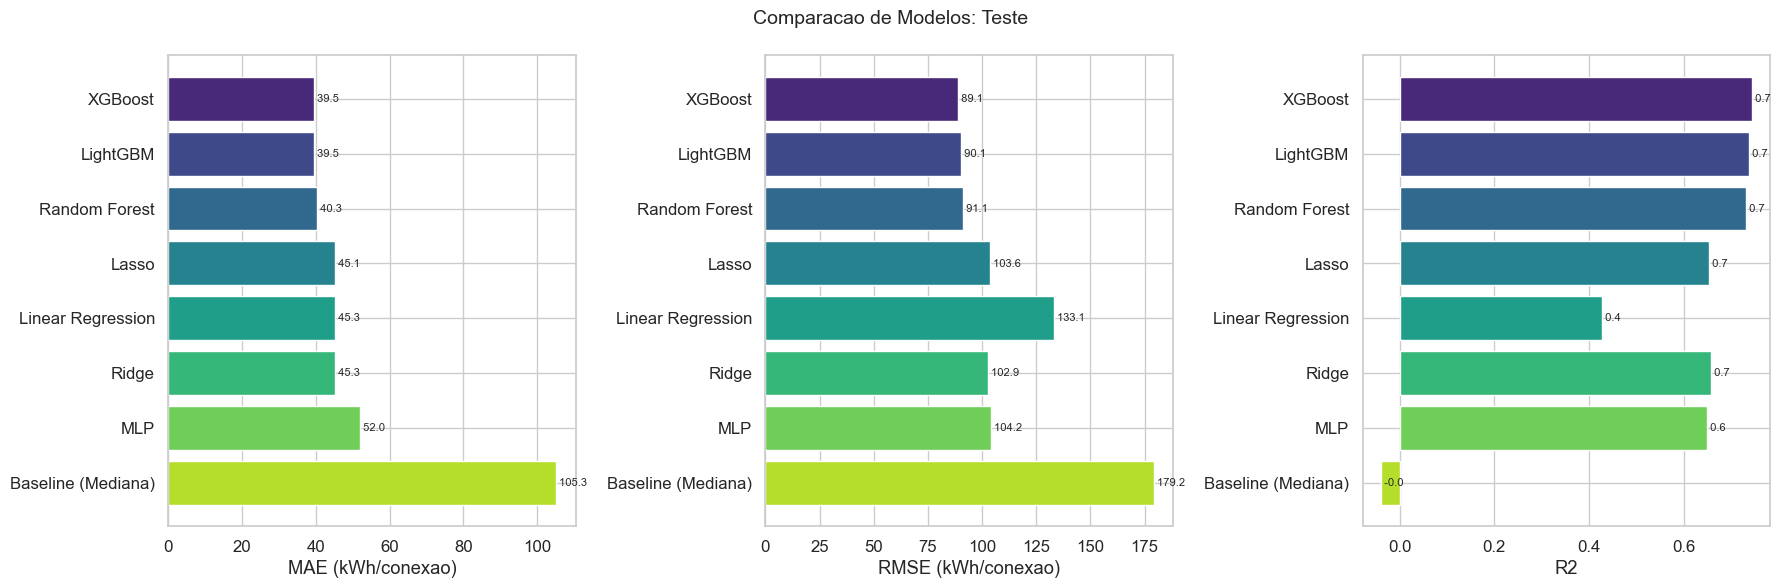

In [121]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Comparacao de Modelos: Teste", fontsize=14)
colors = sns.color_palette("viridis", len(res_df))

for ax, col, lab in zip(
    axes,
    ["MAE", "RMSE", "R2"],
    ["MAE (kWh/conexao)", "RMSE (kWh/conexao)", "R2"],
):
    bars = ax.barh(res_df["Modelo"], res_df[col], color=colors)
    ax.set_xlabel(lab)
    ax.invert_yaxis()
    for b, v in zip(bars, res_df[col]):
        ax.text(b.get_width(), b.get_y() + b.get_height() / 2, f" {v:.1f}", va="center", fontsize=8)

plt.tight_layout()
plt.show()


### Predicoes vs valores reais (escala original)


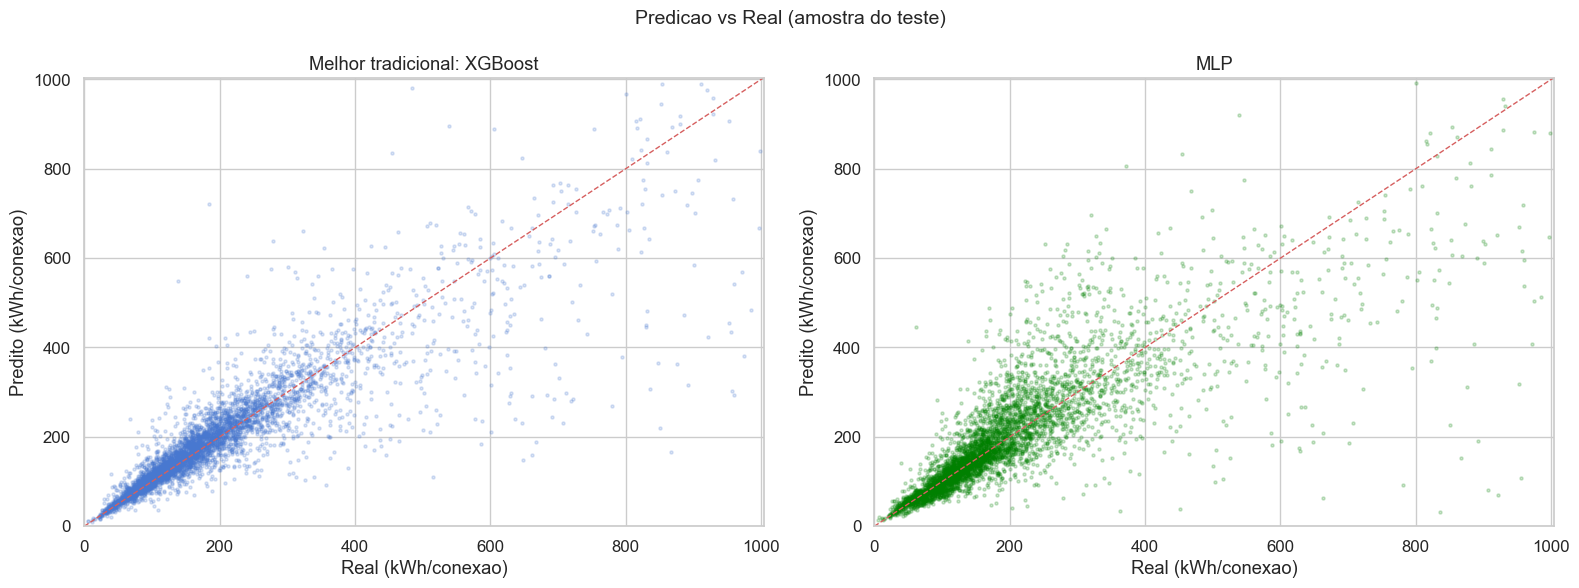

In [122]:
best_name = res_df[
    ~res_df["Modelo"].isin(["Baseline (Mediana)", "MLP"])
].iloc[0]["Modelo"]
best_key = {
    "Linear Regression": "Linear", "Ridge": "Ridge", "Lasso": "Lasso",
    "Random Forest": "RF", "XGBoost": "XGBoost", "LightGBM": "LightGBM",
}.get(best_name, best_name)

rng = np.random.default_rng(SEED)
plot_idx = rng.choice(len(y_test_orig), size=min(5000, len(y_test_orig)), replace=False)
lim_high = np.quantile(
    np.concatenate([y_test_orig, preds[best_key], preds["MLP"]]),
    0.995
)
lim = [0, lim_high]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Predicao vs Real (amostra do teste)", fontsize=14)

ax = axes[0]
ax.scatter(y_test_orig[plot_idx], preds[best_key][plot_idx], alpha=0.2, s=5)
ax.plot(lim, lim, "r--", linewidth=1)
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("Real (kWh/conexao)")
ax.set_ylabel("Predito (kWh/conexao)")
ax.set_title(f"Melhor tradicional: {best_name}")

ax = axes[1]
ax.scatter(y_test_orig[plot_idx], preds["MLP"][plot_idx], alpha=0.2, s=5, color="green")
ax.plot(lim, lim, "r--", linewidth=1)
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("Real (kWh/conexao)")
ax.set_ylabel("Predito (kWh/conexao)")
ax.set_title("MLP")

plt.tight_layout()
plt.show()


### Curva de aprendizado: MLP

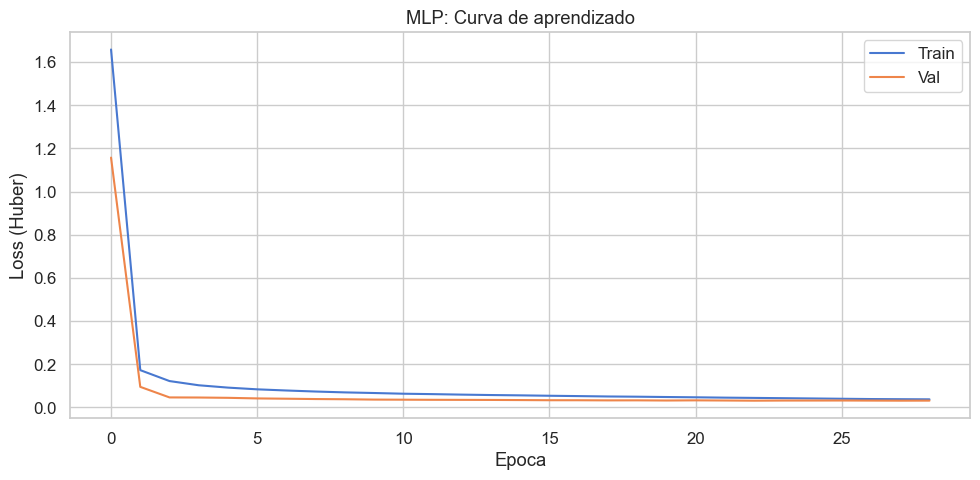

In [123]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(hist_mlp.history["loss"], label="Train")
ax.plot(hist_mlp.history["val_loss"], label="Val")
ax.set_xlabel("Epoca")
ax.set_ylabel("Loss (Huber)")
ax.set_title("MLP: Curva de aprendizado")
ax.legend()
plt.tight_layout()
plt.show()


## 12. Importancia de features

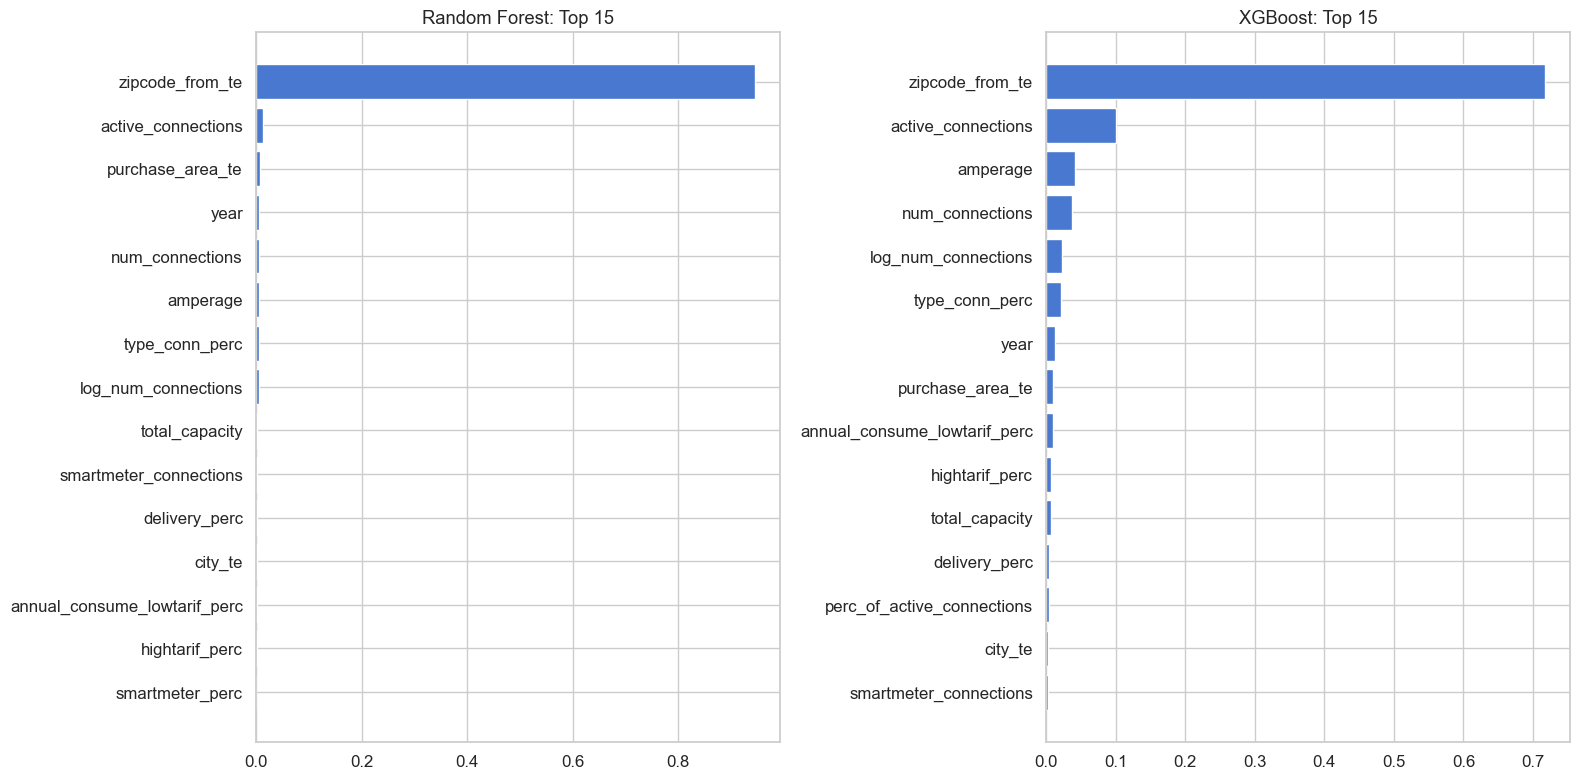


Ridge: Top 10 coeficientes (|valor|):
  zipcode_from_te                0.5307
  log_num_connections            0.1108
  amperage                       0.0534
  type_conn_perc                 0.0421
  smartmeter_connections         0.0315
  year                           0.0234
  num_connections                0.0206
  smartmeter_perc                0.0198
  total_capacity                 0.0181
  city_te                        0.0159


In [124]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

imp_rf = pd.Series(m_rf.feature_importances_, index=FEAT_COLS).nlargest(15)
imp_xgb = pd.Series(m_xgb.feature_importances_, index=FEAT_COLS).nlargest(15)

axes[0].barh(imp_rf.index[::-1], imp_rf.values[::-1])
axes[0].set_title("Random Forest: Top 15")

axes[1].barh(imp_xgb.index[::-1], imp_xgb.values[::-1])
axes[1].set_title("XGBoost: Top 15")

plt.tight_layout()
plt.show()

print("\nRidge: Top 10 coeficientes (|valor|):")
coefs = pd.Series(np.abs(m_ridge.coef_), index=FEAT_COLS).nlargest(10)
for f, v in coefs.items():
    print(f"  {f:<30s} {v:.4f}")


## 13. Distribuicao dos erros (escala original)


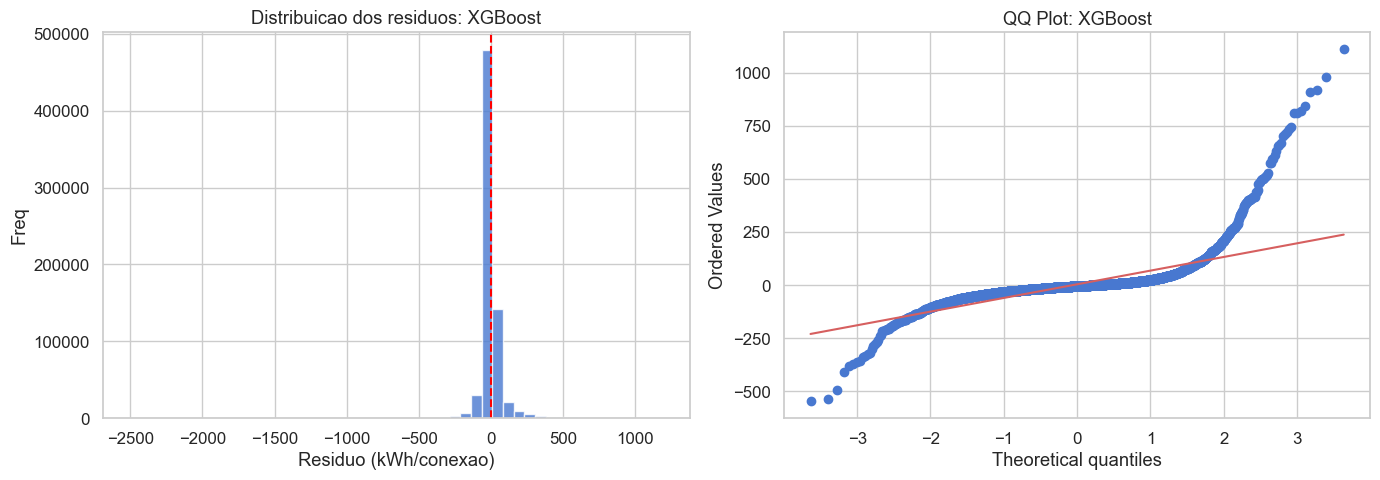

In [125]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

residuals = y_test_orig - preds[best_key]
residual_sample = residuals[np.random.default_rng(SEED).choice(len(residuals), size=min(5000, len(residuals)), replace=False)]

ax = axes[0]
ax.hist(residuals, bins=50, edgecolor="white", alpha=0.8)
ax.axvline(0, color="red", ls="--")
ax.set_xlabel("Residuo (kWh/conexao)")
ax.set_ylabel("Freq")
ax.set_title(f"Distribuicao dos residuos: {best_name}")

from scipy import stats
ax = axes[1]
stats.probplot(residual_sample, plot=ax)
ax.set_title(f"QQ Plot: {best_name}")

plt.tight_layout()
plt.show()
